#  Apple Prices <hr style="border:2.5px solid #fa6194ff"></hr>

<b> Elyssa Tombale </b>
<br>T09-A</br>

In [111]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [112]:
# load dataset
df = pd.read_csv(r"online vs store shopping dataset.csv",
                 delimiter=",")
df

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11784,67,151087,10.4,4,2.2,2,5,42,4,70860,...,9,9,7,2,8,7,6,Other,Tier 1,Store
11785,60,243273,6.1,10,3.0,3,2,20,14,90420,...,4,7,10,8,2,1,10,Female,Tier 2,Store
11786,53,154729,4.6,13,1.8,8,2,11,15,18700,...,5,9,1,3,4,6,1,Female,Tier 2,Store
11787,65,66116,6.2,3,1.0,1,1,31,0,61475,...,1,7,10,10,2,2,9,Other,Tier 1,Store


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [114]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [115]:
columns = ['avg_online_spend','avg_store_spend']

means_data = {col: [] for col in columns}

np.random.seed(42)

for _ in range(50):  # 50 samples
    for c in columns:
        sample = np.random.choice(df[c], size=30, replace=True)
        means_data[c].append(np.mean(sample))

df_means = pd.DataFrame(means_data)

print(df_means)


    avg_online_spend  avg_store_spend
0       81411.800000     80148.100000
1       78153.500000     80986.600000
2       83486.000000     85873.733333
3       82418.800000     64988.600000
4       70022.133333     83961.566667
5       73456.800000     78058.666667
6       75389.166667     58041.800000
7       68169.233333     78174.633333
8       77352.833333     69313.633333
9       87266.066667     83791.033333
10      72701.466667     78436.633333
11      87467.900000     74061.566667
12      73730.400000     68739.566667
13      75279.966667     70100.366667
14      73664.300000     80272.233333
15      78461.566667     85727.233333
16      78569.433333     85057.666667
17      83828.966667     72301.566667
18      75279.466667     71275.133333
19      69688.033333     77073.933333
20      81969.666667     83795.000000
21      72974.066667     78568.533333
22      69980.066667     60859.700000
23      87687.300000     73157.666667
24      64893.066667     67243.633333
25      7813

In [116]:
#CLT Dataset
df_means.to_csv("shopping_clt_dataset.csv", index=False)

In [117]:
df = pd.read_csv("shopping_clt_dataset.csv")

In [118]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_online_spend  50 non-null     float64
 1   avg_store_spend   50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [119]:
df.describe()

,avg_online_spend,avg_store_spend
count,50.000000,50.000000
mean,76427.649333,75087.232000
std,6506.440323,8008.095901
min,64893.066667,58041.800000
25%,71138.416667,69522.766667
50%,75552.366667,75462.866667
75%,82393.250000,80891.808333
max,87687.300000,91251.000000


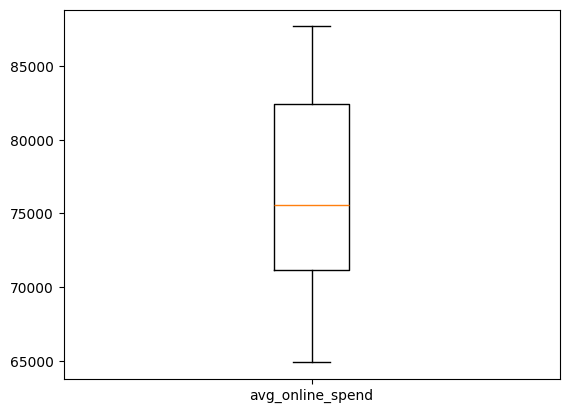

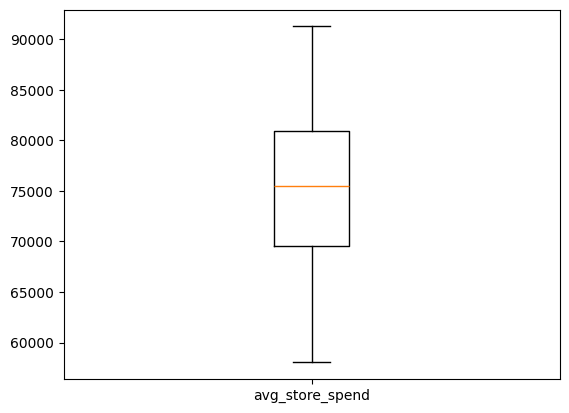

In [120]:
#Outlier Detection
plt.boxplot(df['avg_online_spend'], tick_labels=['avg_online_spend'])
plt.show()

plt.boxplot(df['avg_store_spend'], tick_labels=['avg_store_spend'])
plt.show()

In [121]:
#Removing 3 Sigma Outliers
z_online = stats.zscore(df['avg_online_spend'])
online_outliers = (z_online < -3) | (z_online > 3)
df = df[~online_outliers]

z_store = stats.zscore(df['avg_store_spend'])
store_outliers = (z_store < -3) | (z_store > 3)
df = df[~store_outliers]



In [122]:
# Save Clean Dataset
df.to_csv("shopping_cleaned.csv", index=False)

In [123]:
#Load Dataset
df = pd.read_csv("shopping_cleaned.csv")

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   avg_online_spend  50 non-null     float64
 1   avg_store_spend   50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


,avg_online_spend,avg_store_spend
count,50.000000,50.000000
mean,76427.649333,75087.232000
std,6506.440323,8008.095901
min,64893.066667,58041.800000
25%,71138.416667,69522.766667
50%,75552.366667,75462.866667
75%,82393.250000,80891.808333
max,87687.300000,91251.000000


In [124]:
#Descriptive Statistics
df[['avg_online_spend','avg_store_spend']].describe()

,avg_online_spend,avg_store_spend
count,50.000000,50.000000
mean,76427.649333,75087.232000
std,6506.440323,8008.095901
min,64893.066667,58041.800000
25%,71138.416667,69522.766667
50%,75552.366667,75462.866667
75%,82393.250000,80891.808333
max,87687.300000,91251.000000


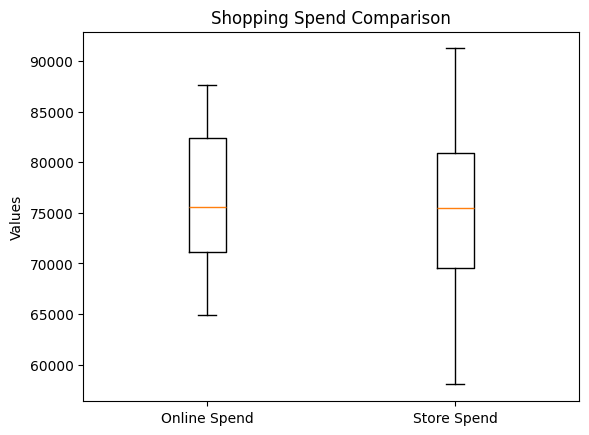

In [125]:
#Boxplot Comparison
plt.boxplot(df[['avg_online_spend','avg_store_spend']],
            tick_labels=['Online Spend','Store Spend'])
plt.title("Shopping Spend Comparison")
plt.ylabel("Values")
plt.show()

In [126]:
#Shapiro-Wilk Normality Test
print("Online Spend:")
w_stat, p_value = stats.shapiro(df['avg_online_spend'])

print("w_stat:", round(w_stat,4))
print("p_value:", round(p_value,4))

alpha = 0.05
if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

print("\nStore Spend:")
w_stat, p_value = stats.shapiro(df['avg_store_spend'])

print("w_stat:", round(w_stat,4))
print("p_value:", round(p_value,4))

if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

Online Spend:
w_stat: 0.9584
p_value: 0.0762
Normal data

Store Spend:
w_stat: 0.984
p_value: 0.7272
Normal data


In [127]:
#F-Test for Equality of Variances
var_online = df['avg_online_spend'].var(ddof=1)
var_store = df['avg_store_spend'].var(ddof=1)

if var_online > var_store:
    f_stat = var_online / var_store
else:
    f_stat = var_store / var_online

print("f_stat =", round(f_stat,4))

dof_o = df['avg_online_spend'].count() - 1
dof_s = df['avg_store_spend'].count() - 1

p_value = 1 - stats.f.cdf(f_stat, dof_o, dof_s)
print("p_value =", round(p_value,4))

alpha = 0.05
if p_value < alpha:
    print("Unequal variances")
else:
    print("Equal variances")

f_stat = 1.5149
p_value = 0.0748
Equal variances


In [128]:
#2-Sample T-Test
# Ho: Online Spend <= Store Spend
# Ha: Online Spend > Store Spend

t_stat, p_value = stats.ttest_ind(
    df['avg_online_spend'],
    df['avg_store_spend'],
    alternative='greater',
    equal_var=True
)

print("t_stat =", round(t_stat,4))
print("p_value =", round(p_value,4))

if p_value < alpha:
    print("Online spending is higher than store spending.")
else:
    print("No significant difference between online and store spending.")

t_stat = 0.9186
p_value = 0.1803
No significant difference between online and store spending.


In [129]:
#Cohen's d
online_mean = df['avg_online_spend'].mean()
store_mean = df['avg_store_spend'].mean()
online_std = df['avg_online_spend'].std(ddof=1)

d = abs((online_mean - store_mean) / online_std)

print("Cohen's d:", round(d,4))

Cohen's d: 0.206


In [130]:
#Power of the Test
power = TTestPower().power(
    effect_size = -d,
    nobs = df['avg_online_spend'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print("Power of the test:", round(power*100,2), "%")

Power of the test: 41.75 %
